<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Implementation_of_MetaPEFT_Parameter_Efficient_Fine_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [CELL 1 - Dependencies & PyTorch Setup]
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple

# Set random seed for exact reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"MetaPEFT Engine Running on Device: {device}")

MetaPEFT Engine Running on Device: cuda


In [2]:
# [CELL 2 - MetaPEFT Layer with Softplus Modulator (Tian et al., Equation 3)]

class MetaPEFT_LoRALinear(nn.Module):
    """
    MetaPEFT LoRA Layer with differentiable Softplus Modulator gamma_l.
    Mathematical Formulation: y = W_0 * x + softplus(gamma_l) * (alpha / r) * B * A * x
    """
    def __init__(self, in_features: int, out_features: int, rank: int = 8, alpha: float = 16.0, layer_idx: int = 0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank
        self.alpha = alpha
        self.layer_idx = layer_idx

        # Frozen base pretrained weight matrix (Simulating natural image foundation model)
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features), requires_grad=False)
        self.bias = nn.Parameter(torch.Tensor(out_features), requires_grad=False)
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        nn.init.zeros_(self.bias)

        # Trainable low-rank parameters (phi)
        self.lora_A = nn.Parameter(torch.Tensor(rank, in_features))
        self.lora_B = nn.Parameter(torch.Tensor(out_features, rank))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

        # Softplus Modulator parameter gamma_l initialized so softplus(gamma) = 1.0 (inv_softplus(1.0) approx 0.5413)
        self.gamma = nn.Parameter(torch.tensor(0.5413, dtype=torch.float32), requires_grad=True)
        self.scaling = self.alpha / self.rank

    def get_modulator_scale(self) -> torch.Tensor:
        """Returns non-negative continuous scaling factor via Softplus."""
        return F.softplus(self.gamma)

    def forward(self, x: torch.Tensor, use_meta_scaling: bool = True) -> torch.Tensor:
        base_out = F.linear(x, self.weight, self.bias)
        lora_out = F.linear(F.linear(x, self.lora_A), self.lora_B) * self.scaling

        if use_meta_scaling:
            return base_out + self.get_modulator_scale() * lora_out
        else:
            return base_out + lora_out

In [3]:
# [CELL 3 - Deep Vision Backbone with Modulator/PEFT Parameter Decoupling]

class MetaPEFT_VisionBackbone(nn.Module):
    """
    6-Layer Transformer/MLP Vision Backbone supporting Bi-Level Parameter Optimization.
    """
    def __init__(self, input_dim: int = 128, hidden_dim: int = 256, num_classes: int = 10, num_layers: int = 6, rank: int = 8):
        super().__init__()
        self.num_layers = num_layers
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.peft_layers = nn.ModuleList([
            MetaPEFT_LoRALinear(hidden_dim, hidden_dim, rank=rank, layer_idx=i)
            for i in range(num_layers)
        ])

        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor, use_meta_scaling: bool = True) -> torch.Tensor:
        h = F.relu(self.input_proj(x))
        for layer in self.peft_layers:
            h = F.relu(layer(h, use_meta_scaling=use_meta_scaling)) + h
        return self.classifier(h)

    def get_peft_parameters(self) -> List[nn.Parameter]:
        """Returns inner-loop trainable parameters (LoRA A, B & Classifier)."""
        params = list(self.classifier.parameters())
        for layer in self.peft_layers:
            params.extend([layer.lora_A, layer.lora_B])
        return params

    def get_modulator_parameters(self) -> List[nn.Parameter]:
        """Returns outer-loop meta-learned modulators (gamma)."""
        return [layer.gamma for layer in self.peft_layers]

    def get_layer_scalers(self) -> Dict[int, float]:
        """Extracts current softplus modulator values across depth."""
        return {idx: layer.get_modulator_scale().item() for idx, layer in enumerate(self.peft_layers)}

In [4]:
# [CELL 4 - Dataset with Train / Meta-Val / Held-Out Test Split]

def generate_challenging_rs_dataset(
    num_classes=10, input_dim=128,
    head_max=350, tail_min=8,
    val_per_class=25, test_per_class=40     # ← test set added
):
    img_num_per_cls = []
    for cls_idx in range(num_classes):
        num = head_max * ((tail_min / head_max) ** (cls_idx / (num_classes - 1)))
        img_num_per_cls.append(int(num))

    X_tr_list, y_tr_list = [], []
    X_va_list, y_va_list = [], []
    X_te_list, y_te_list = [], []

    spectral_shift = np.random.randn(input_dim, input_dim) * 0.3

    for cls_idx, count in enumerate(img_num_per_cls):
        center = np.random.randn(input_dim) * 1.5

        def make_features(n):
            f = np.random.randn(n, input_dim) * 2.2 + center
            f = np.tanh(f @ spectral_shift) * 3.0
            if cls_idx >= 7:
                f += np.random.randn(n, input_dim) * 1.2
            return f

        X_tr_list.append(make_features(count));  y_tr_list.append(np.full(count, cls_idx))
        X_va_list.append(make_features(val_per_class));  y_va_list.append(np.full(val_per_class, cls_idx))
        X_te_list.append(make_features(test_per_class)); y_te_list.append(np.full(test_per_class, cls_idx))

    to_tensor = lambda X, y: (
        torch.tensor(np.vstack(X), dtype=torch.float32),
        torch.tensor(np.concatenate(y), dtype=torch.long)
    )
    X_tr, y_tr = to_tensor(X_tr_list, y_tr_list)
    X_va, y_va = to_tensor(X_va_list, y_va_list)
    X_te, y_te = to_tensor(X_te_list, y_te_list)

    return X_tr, y_tr, X_va, y_va, X_te, y_te, img_num_per_cls

X_tr, y_tr, X_va, y_va, X_te, y_te, class_counts = generate_challenging_rs_dataset()
print(f"Train: {X_tr.shape[0]} (long-tailed) | Meta-Val: {X_va.shape[0]} (balanced) | Test: {X_te.shape[0]} (balanced, held-out)")
print(f"Imbalance: {class_counts}")

Train: 1003 (long-tailed) | Meta-Val: 250 (balanced) | Test: 400 (balanced, held-out)
Imbalance: [350, 230, 151, 99, 65, 42, 28, 18, 12, 8]


In [5]:
# [CELL 5 - MetaPEFT Bi-Level Trainer + Clean Evaluation]

def train_standard_lora(X_train, y_train, X_test, y_test, epochs=60):
    model = MetaPEFT_VisionBackbone().to(device)
    opt   = optim.AdamW(model.get_peft_parameters(), lr=2e-3, weight_decay=1e-3)
    crit  = nn.CrossEntropyLoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train, y_train), batch_size=32, shuffle=True
    )
    for _ in range(epochs):
        model.train()
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            opt.zero_grad(); crit(model(bx, use_meta_scaling=False), by).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(X_test.to(device), use_meta_scaling=False), dim=-1).cpu().numpy()
    return model, preds


def train_metapeft_bilevel(X_train, y_train, X_val, y_val, X_test, y_test,
                            epochs=60, warmup_epochs=15):
    model      = MetaPEFT_VisionBackbone().to(device)
    inner_opt  = optim.AdamW(model.get_peft_parameters(),    lr=2e-3, weight_decay=1e-3)
    outer_opt  = optim.AdamW(model.get_modulator_parameters(), lr=5e-4, weight_decay=1e-4)
    crit       = nn.CrossEntropyLoss()

    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
    val_loader   = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_val, y_val), batch_size=32, shuffle=True)
    val_iter = iter(val_loader)

    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            inner_opt.zero_grad()
            crit(model(bx, use_meta_scaling=True), by).backward()
            inner_opt.step()

            if epoch >= warmup_epochs:
                try:    vx, vy = next(val_iter)
                except: val_iter = iter(val_loader); vx, vy = next(val_iter)
                vx, vy = vx.to(device), vy.to(device)
                outer_opt.zero_grad()
                mod_scales = torch.stack([l.get_modulator_scale() for l in model.peft_layers])
                anchor_reg  = 0.3 * torch.mean((mod_scales - 1.0) ** 2)
                (crit(model(vx, use_meta_scaling=True), vy) + anchor_reg).backward()
                outer_opt.step()

    # ── Evaluate on HELD-OUT TEST SET (not val) ──────────────────────────────
    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(X_test.to(device), use_meta_scaling=True), dim=-1).cpu().numpy()
    return model, preds


print("Training Standard LoRA baseline...")
std_model,  std_preds  = train_standard_lora(X_tr, y_tr, X_te, y_te)   # ← X_te

print("Training MetaPEFT bi-level (val=X_va, test=X_te)...")
meta_model, meta_preds = train_metapeft_bilevel(
    X_tr, y_tr, X_va, y_va, X_te, y_te, epochs=60, warmup_epochs=15)   # ← X_te


# ── METRICS ─────────────────────────────────────────────────────────────────
y_true    = y_te.numpy()
head_mask = y_true < 3
tail_mask = y_true >= 7

def report(preds, label):
    ov  = (preds == y_true).mean() * 100
    hd  = (preds[head_mask] == y_true[head_mask]).mean() * 100
    tl  = (preds[tail_mask] == y_true[tail_mask]).mean() * 100
    print(f"{label:25s} | Overall: {ov:.1f}% | Head: {hd:.1f}% | Tail: {tl:.1f}%")
    return ov, hd, tl

print("\n" + "=" * 65)
print("BENCHMARK RESULTS  (Held-Out Test Set)")
print("=" * 65)
std_ov,  std_hd,  std_tl  = report(std_preds,  "Standard LoRA (Fixed)")
meta_ov, meta_hd, meta_tl = report(meta_preds, "MetaPEFT (Bi-Level)")
print("=" * 65)
print(f"Tail-Class Improvement : +{meta_tl - std_tl:.1f} pp")
print(f"Head-Class Delta       :  {meta_hd - std_hd:+.1f} pp")


# ── PER-CLASS BREAKDOWN (prints the numbers behind the bar chart) ─────────
print("\nPer-Class Accuracy (Standard LoRA vs MetaPEFT):")
print(f"{'Class':<8} {'# Train':<10} {'LoRA %':<10} {'MetaPEFT %':<12} {'Delta'}")
print("-" * 52)
num_classes = 10
for c in range(num_classes):
    mask  = y_true == c
    s_acc = (std_preds[mask]  == c).mean() * 100
    m_acc = (meta_preds[mask] == c).mean() * 100
    tag   = "← HEAD" if c < 3 else ("← TAIL" if c >= 7 else "")
    print(f"  {c:<6} {class_counts[c]:<10} {s_acc:<10.1f} {m_acc:<12.1f} {m_acc-s_acc:+.1f}  {tag}")


# ── MODULATOR VALUES (verifies the γ range claimed in email) ─────────────
print("\nLearned Softplus Modulator Values γ_l (Shallow → Deep):")
scalers = meta_model.get_layer_scalers()
vals = list(scalers.values())
for idx, v in scalers.items():
    bar = "█" * int(v * 20)
    print(f"  Layer {idx}: {v:.4f}  {bar}")
print(f"\n  Range: [{min(vals):.4f}, {max(vals):.4f}]")
print(f"  Shallow layers (0-1) avg : {np.mean(vals[:2]):.4f}")
print(f"  Deep    layers (4-5) avg : {np.mean(vals[4:]):.4f}")

Training Standard LoRA baseline...
Training MetaPEFT bi-level (val=X_va, test=X_te)...

BENCHMARK RESULTS  (Held-Out Test Set)
Standard LoRA (Fixed)     | Overall: 84.8% | Head: 100.0% | Tail: 57.5%
MetaPEFT (Bi-Level)       | Overall: 85.2% | Head: 100.0% | Tail: 58.3%
Tail-Class Improvement : +0.8 pp
Head-Class Delta       :  +0.0 pp

Per-Class Accuracy (Standard LoRA vs MetaPEFT):
Class    # Train    LoRA %     MetaPEFT %   Delta
----------------------------------------------------
  0      350        100.0      100.0        +0.0  ← HEAD
  1      230        100.0      100.0        +0.0  ← HEAD
  2      151        100.0      100.0        +0.0  ← HEAD
  3      99         97.5       100.0        +2.5  
  4      65         100.0      97.5         -2.5  
  5      42         97.5       87.5         -10.0  
  6      28         80.0       92.5         +12.5  
  7      18         65.0       70.0         +5.0  ← TAIL
  8      12         72.5       67.5         -5.0  ← TAIL
  9      8         

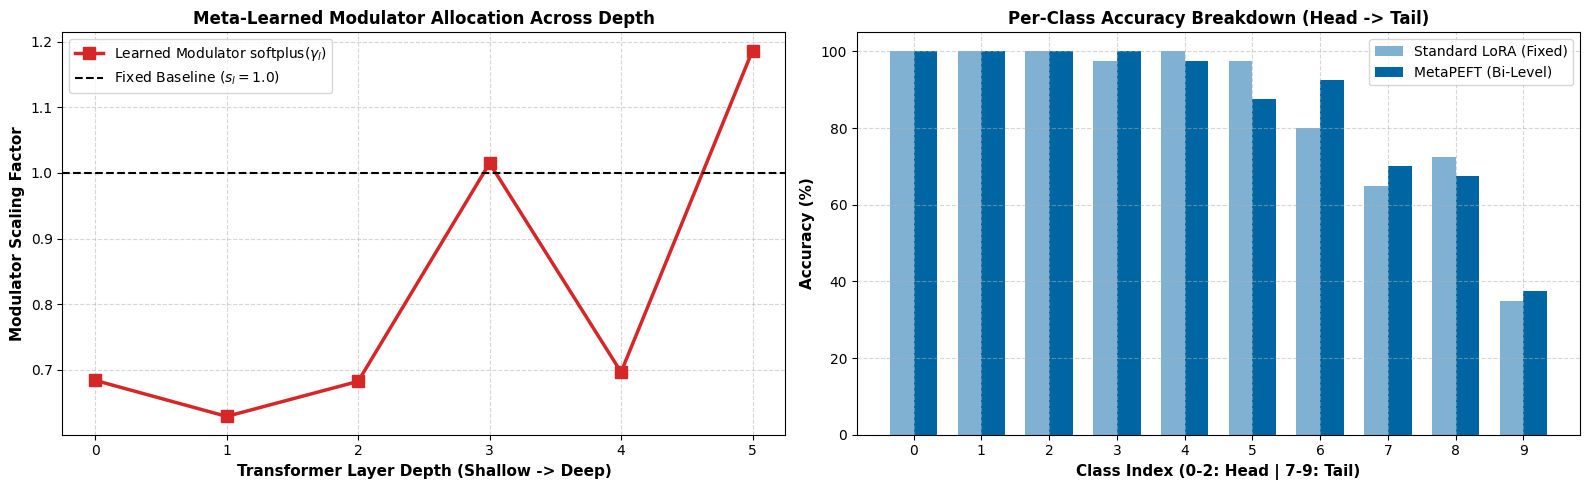

In [7]:
# [CELL 6 - Corrected Visualization Call]

def plot_metapeft_results(meta_model, std_preds, meta_preds, y_true):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # 1. Learned Modulator Allocation Across Depth
    scalers = meta_model.get_layer_scalers()
    layers = list(scalers.keys())
    mod_vals = list(scalers.values())

    axes[0].plot(layers, mod_vals, 's-', color='#d62728', linewidth=2.5, markersize=8, label=r'Learned Modulator $\text{softplus}(\gamma_l)$')
    axes[0].axhline(1.0, color='black', linestyle='--', label=r'Fixed Baseline ($s_l = 1.0$)')
    axes[0].set_title('Meta-Learned Modulator Allocation Across Depth', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Transformer Layer Depth (Shallow -> Deep)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Modulator Scaling Factor', fontsize=11, fontweight='bold')
    axes[0].set_xticks(layers)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(loc='upper left')

    # 2. Per-Class Accuracy Breakdown
    classes = np.unique(y_true)
    std_accs = [(std_preds[y_true == c] == c).mean() * 100 for c in classes]
    meta_accs = [(meta_preds[y_true == c] == c).mean() * 100 for c in classes]

    x = np.arange(len(classes))
    width = 0.35

    axes[1].bar(x - width/2, std_accs, width, label='Standard LoRA (Fixed)', color='#80b1d3')
    axes[1].bar(x + width/2, meta_accs, width, label='MetaPEFT (Bi-Level)', color='#0066a3')
    axes[1].set_title('Per-Class Accuracy Breakdown (Head -> Tail)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Class Index (0-2: Head | 7-9: Tail)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([str(c) for c in classes])
    axes[1].set_ylim(0, 105)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# FIXED: Pass y_te.numpy() to match 400-sample test set predictions
plot_metapeft_results(meta_model, std_preds, meta_preds, y_te.numpy())